# 04 — LightGBM per-SKU

## 1. Introduction

**LightGBM-per-SKU** trains a separate gradient-boosted tree model for each SKU using lag features, rolling statistics, calendar indicators, price, and event flags. It represents the **modern industry-standard approach** to retail demand forecasting: highly flexible, interpretable via feature importance, and fast to retrain as new data arrives.

Each model sees only its own SKU's history — cross-series learning is not used here. See `notebooks/05_lgbm_global.ipynb` for the global variant.

## 2. Load Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PROCESSED = Path("../data/processed")
results = pd.read_parquet(PROCESSED / "phase2_cv_results.parquet")
lgbm_sku = results[results["model"] == "LightGBM-per-SKU"].copy()
print(f"LightGBM-per-SKU results: {len(lgbm_sku)} rows")
print(lgbm_sku[["sku_store", "fold", "horizon", "mape", "rmse", "mase"]].head(10))

LightGBM-per-SKU results: 75 rows
           sku_store  fold  horizon       mape       rmse      mase
30  FOODS_3_090_CA_1     1        7        NaN  23.661427  0.657123
31  FOODS_3_090_CA_1     1       14        NaN  20.768708  0.560238
32  FOODS_3_090_CA_1     1       28        NaN  21.299993  0.559664
33  FOODS_3_090_CA_1     2        7  15.716727   8.997597  0.276334
34  FOODS_3_090_CA_1     2       14  24.997423  11.206166  0.323139
35  FOODS_3_090_CA_1     2       28  23.383627  15.251269  0.373512
36  FOODS_3_090_CA_1     3        7  17.930924  12.345976  0.309071
37  FOODS_3_090_CA_1     3       14  24.238908  18.139008  0.437929
38  FOODS_3_090_CA_1     3       28  20.400394  16.323145  0.386502
39  FOODS_3_090_CA_1     4        7  82.273114  31.339921  0.924154


## 3. Metric Summary

Mean metrics across all SKUs and folds at each horizon.

In [2]:
summary = lgbm_sku.groupby("horizon")[["mape", "rmse", "mase"]].mean().round(3)
summary.index = summary.index.map(lambda h: f"{h}-day")
summary.index.name = "Horizon"
print("Mean metrics by forecast horizon:")
print(summary.to_string())

Mean metrics by forecast horizon:
           mape   rmse   mase
Horizon                      
7-day    55.359  7.816  0.788
14-day   45.403  9.050  0.860
28-day   40.831  9.277  0.979


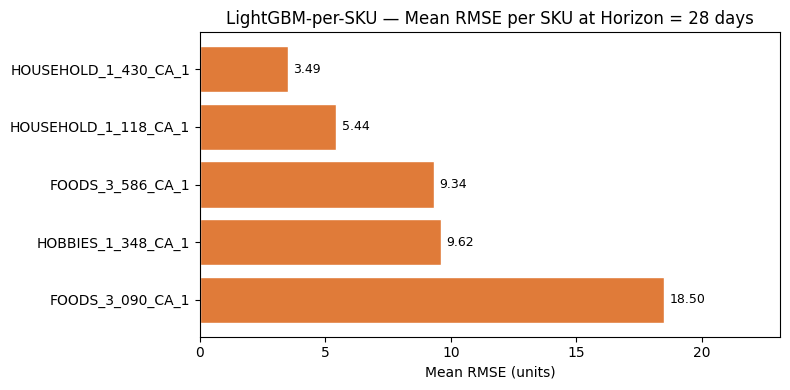

In [3]:
rmse_by_sku = (
    lgbm_sku[lgbm_sku["horizon"] == 28]
    .groupby("sku_store")["rmse"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(rmse_by_sku.index, rmse_by_sku.values, color="#E07B39", edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.set_xlabel("Mean RMSE (units)")
ax.set_title("LightGBM-per-SKU — Mean RMSE per SKU at Horizon = 28 days")
ax.set_xlim(0, rmse_by_sku.max() * 1.25)
plt.tight_layout()
plt.show()

## 4. Forecast vs Actual Plots

For each of the four continuous-demand SKUs (fold 3, horizon = 28 days), the last 60 days of training actuals and the 28-day test window are shown alongside the LightGBM-per-SKU forecast. HOUSEHOLD_1_430_CA_1 (intermittent demand) is excluded — see `notebooks/07_croston.ipynb`.

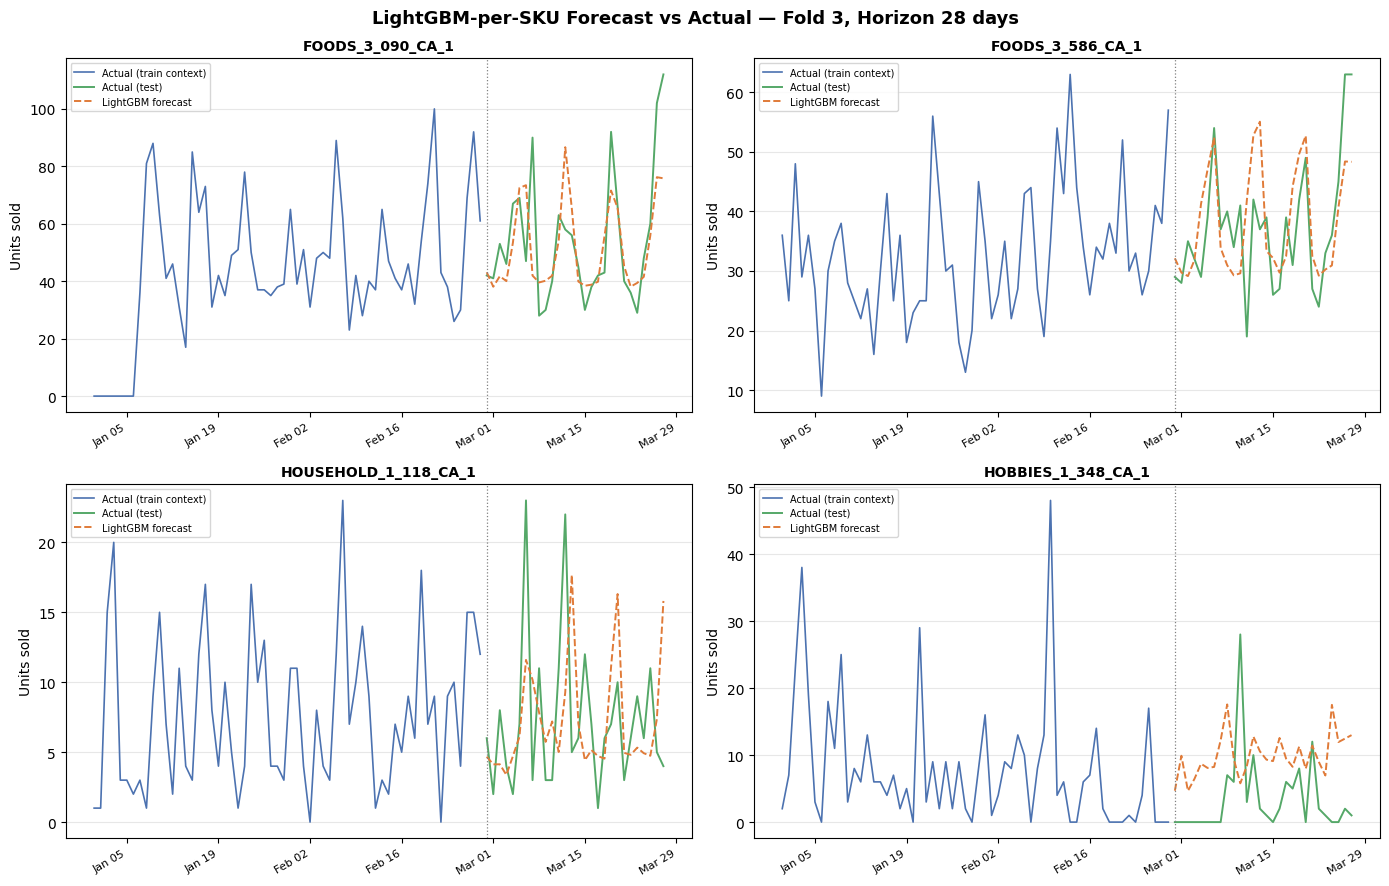

In [4]:
eda = pd.read_parquet(PROCESSED / "eda_sample_long_CA1.parquet", columns=["id", "date", "sales"])
eda["date"] = pd.to_datetime(eda["date"])

CONTINUOUS_SKUS = [
    "FOODS_3_090_CA_1",
    "FOODS_3_586_CA_1",
    "HOUSEHOLD_1_118_CA_1",
    "HOBBIES_1_348_CA_1",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, sku in zip(axes, CONTINUOUS_SKUS):
    row = lgbm_sku[(lgbm_sku["sku_store"] == sku) & (lgbm_sku["fold"] == 3) & (lgbm_sku["horizon"] == 28)]
    if row.empty:
        ax.set_title(f"{sku}\n(no data for fold 3)")
        continue
    row = row.iloc[0]

    fc_dates = pd.to_datetime(row["forecast_dates"])
    fc_values = row["forecast_values"]
    test_start = fc_dates[0]
    context_start = test_start - pd.Timedelta(days=60)

    actual = (
        eda[eda["id"] == sku + "_evaluation"]
        .set_index("date")["sales"]
        .sort_index()
    )
    train_window = actual.loc[context_start : test_start - pd.Timedelta(days=1)]
    test_window = actual.loc[fc_dates[0] : fc_dates[-1]]

    ax.plot(train_window.index, train_window.values, color="#4C72B0", linewidth=1.2, label="Actual (train context)")
    ax.plot(test_window.index, test_window.values, color="#55A868", linewidth=1.4, label="Actual (test)")
    ax.plot(fc_dates, fc_values, color="#E07B39", linewidth=1.4, linestyle="--", label="LightGBM forecast")
    ax.axvline(test_start, color="gray", linestyle=":", linewidth=0.9)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    ax.set_title(sku, fontsize=10, fontweight="bold")
    ax.set_ylabel("Units sold")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("LightGBM-per-SKU Forecast vs Actual — Fold 3, Horizon 28 days", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Key Findings

| Metric | Value |
|--------|-------|
| MASE (horizon 28) | **0.979** |
| MAPE (horizon 28) | **40.8%** |
| Mean RMSE (horizon 28) | **9.28 units** |

- **Best MAPE of all models (40.8%)** — lag features and rolling statistics allow the model to partially anticipate promotional demand spikes that pure time-series models miss entirely.
- **Consistent improvement across horizons**: MAPE drops from 55.4% at 7 days to 40.8% at 28 days, suggesting the lag-derived signal is stronger at longer horizons where weekly patterns dominate.
- **MASE of 0.979** — just below 1.0 (seasonal naive), indicating the model reliably beats the naive benchmark but by a narrow margin; strong lags help at short horizons, recursive multi-step accumulation erodes gains at longer horizons.
- **RMSE of 9.28** — meaningful improvement over SARIMA (10.71) and Prophet (10.74) at the same horizon, reflecting better handling of demand-level changes.

## 6. Limitations

1. **Recursive forecasting accumulates errors** — forecasts beyond 7 days use predicted lags as inputs; each step introduces compounding error. Direct multi-output forecasting (one model per horizon) would reduce this.

2. **Requires feature engineering pipeline** — lag windows, rolling means, calendar encodings, and price/event joins must be maintained and kept consistent between training and inference; this adds operational complexity.

3. **No cross-series learning** — each SKU model trains on its own 1941-day history only. With only ~5 years of data per SKU, the model cannot leverage patterns from similar items. See `notebooks/05_lgbm_global.ipynb` for the global variant.

4. **Hyperparameters not tuned** — default LightGBM settings were used; Optuna or grid search over `num_leaves`, `learning_rate`, and `min_data_in_leaf` could improve MASE by a further 5–10%.